# Building a 1-D CNN (Temporal Convolution Network) Classifier

## 0. Imports and Config

In [1]:
%load_ext autoreload
%autoreload 2

import ast

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# from helpers import plotLightCurveFromDF, sampleRandomKIC, saveLightCurveFromDF
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Set model training device. For Apple Silicon, the device is mps.

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)


mps


---

## 1. Read and Preprocess Dataset

In [3]:
df = pd.read_parquet("./local-assets/MERGED_LCS.parquet")
df


,time,flux,Class
KIC,,,
757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051...",CANDIDATE
1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",FALSE POSITIVE
1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
...,...,...,...
202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR
202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR
202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE


In [4]:
df = df.reset_index()


### 1.1. Schema

Rename features


In [5]:
renameMap = {
    'Class': 'class',
}

df = df.rename(columns=renameMap)
df


,KIC,time,flux,class
0,757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
1,892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
2,1025986,"[120.53931629149156, 120.55975094284076, 120.5...","[1.0488531548750866, 1.0523113529281902, 1.051...",CANDIDATE
3,1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",FALSE POSITIVE
4,1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
...,...,...,...,...
18877,202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR
18878,202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR
18879,202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE
18880,202140094,"[1940.0088592208049, 1940.029290861763, 1940.0...","[1.008090615272522, 1.0085946321487427, 1.0099...",FALSE POSITIVE


Remove duplicate KIC entries

In [6]:
def chooseLabel(labels):
    labels = list(labels)
    nonFp = [lab for lab in labels if lab != "FALSE POSITIVE"]

    if len(nonFp) > 0:
        # If there are multiple non-FP labels, take the most common one
        return pd.Series(nonFp).mode().iloc[0]

    # If all labels are FALSE POSITIVE, keep one of them
    return pd.Series(labels).mode().iloc[0]


In [7]:
df = (
    df.groupby("KIC", as_index=False)
        .agg({
            "time": "first",
            "flux": "first",
            "class": chooseLabel
        })
)


In [8]:
df['class'].value_counts()


class
FALSE POSITIVE           7522
ECLIPSING BINARY STAR    3049
VARIABLE STAR            2980
CONFIRMED                1972
CANDIDATE                1637
Name: count, dtype: int64

In [9]:
df.duplicated(subset="KIC").sum()


np.int64(0)

Remove 'CANDIDATE' class

In [10]:
df = df[df['class'] != 'CANDIDATE'].copy()


In [11]:
df


,KIC,time,flux,class
0,757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED
1,892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE
3,1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",ECLIPSING BINARY STAR
4,1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED
5,1027438,"[131.51268857505056, 131.53312328704487, 131.5...","[1.0649623994019086, 1.0653504391733866, 1.065...",FALSE POSITIVE
...,...,...,...,...
17155,202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR
17156,202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR
17157,202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE
17158,202140094,"[1940.0088592208049, 1940.029290861763, 1940.0...","[1.008090615272522, 1.0085946321487427, 1.0099...",FALSE POSITIVE


Encode labels

In [12]:
def encodeLabels(df):
    """
    Function to encode the labels in the 'Class' feature of a given dataframe df.
    """
    le = LabelEncoder()
    y = le.fit_transform(df["class"].values)
    df = df.copy()
    df["label"] = y

    return df, le


In [13]:
df, le = encodeLabels(df)
df


,KIC,time,flux,class,label
0,757450,"[131.51271468758932, 131.5331494016791, 131.55...","[1.0392150925008297, 1.0383358659303283, 1.038...",CONFIRMED,0
1,892772,"[352.39657371611975, 352.43743948176416, 352.4...","[1.019566672226177, 1.0188446568700726, 1.0189...",FALSE POSITIVE,2
3,1026032,"[131.5127135392686, 131.53314824846893, 131.55...","[1.0509398498643578, 1.0503349421979056, 1.050...",ECLIPSING BINARY STAR,1
4,1026957,"[120.53930025400041, 120.55973490802717, 120.5...","[1.0599377280481261, 1.0591694377327983, 1.058...",CONFIRMED,0
5,1027438,"[131.51268857505056, 131.53312328704487, 131.5...","[1.0649623994019086, 1.0653504391733866, 1.065...",FALSE POSITIVE,2
...,...,...,...,...,...
17155,202140012,"[1940.0083829938958, 1940.0288146129678, 1940....","[0.9961692094802856, 0.9965322613716125, 0.996...",VARIABLE STAR,3
17156,202140013,"[1940.0083988461702, 1940.0288304660571, 1940....","[0.9897362589836121, 0.9907680153846741, 0.991...",VARIABLE STAR,3
17157,202140059,"[1940.0088655664877, 1940.0292972054667, 1940....","[1.0229097604751587, 1.014359951019287, 1.0042...",FALSE POSITIVE,2
17158,202140094,"[1940.0088592208049, 1940.029290861763, 1940.0...","[1.008090615272522, 1.0085946321487427, 1.0099...",FALSE POSITIVE,2


### 1.2. Light curve raw data preprocessing


In [14]:
def to_1d_float_array(x):
    if isinstance(x, str):
        x = ast.literal_eval(x)
    return np.asarray(x, dtype=np.float32).reshape(-1)


def clean_time_flux(time, flux):
    time = to_1d_float_array(time)
    flux = to_1d_float_array(flux)

    if len(time) == 0 or len(flux) == 0:
        return None, None

    n = min(len(time), len(flux))
    time = time[:n]
    flux = flux[:n]

    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]

    if len(time) < 2:
        return None, None

    return time, flux


def normalize_flux(flux):
    flux = np.asarray(flux, dtype=np.float32)

    if len(flux) == 0:
        return None

    med = np.median(flux)
    if not np.isfinite(med) or med == 0:
        med = 1.0

    return flux / med - 1.0


def clip_flux(flux, clip_sigma=5.0):
    mu = np.mean(flux)
    sd = np.std(flux)

    if np.isfinite(sd) and sd > 0:
        lo, hi = mu - clip_sigma * sd, mu + clip_sigma * sd
        return np.clip(flux, lo, hi)

    return flux


def resample_to_fixed_length(time, flux, seq_len=2000):
    if len(time) < 2:
        return None

    order = np.argsort(time)
    time = time[order]
    flux = flux[order]

    uniq_time, uniq_idx = np.unique(time, return_index=True)
    time = uniq_time
    flux = flux[uniq_idx]

    if len(time) < 2:
        return None

    t_new = np.linspace(time.min(), time.max(), seq_len)
    y_new = np.interp(t_new, time, flux).astype(np.float32)

    return y_new


def standardize_flux(flux):
    x = flux - np.mean(flux)
    std = np.std(x)

    if np.isfinite(std) and std > 0:
        x = x / std

    return x


def preprocess_light_curve(time, flux, seq_len=2000):
    time, flux = clean_time_flux(time, flux)
    if time is None:
        return None

    flux = normalize_flux(flux)
    if flux is None:
        return None

    flux = clip_flux(flux)

    x = resample_to_fixed_length(time, flux, seq_len)
    if x is None:
        return None

    x = standardize_flux(x)

    return x.astype(np.float32)


In [15]:
def preprocess_dataframe(df, seq_len=2000):
    processed_rows = []
    
    for _, row in df.iterrows():
        x = preprocess_light_curve(row["time"], row["flux"], seq_len=seq_len)

        if x is None:
            continue  # skip bad rows

        appendDict = {
            "KIC": row["KIC"],
            "x": x,
            "label": row["label"],
            "class": row['class']
        }

        processed_rows.append(appendDict)

    return pd.DataFrame(processed_rows)


#### 1.2.1 Process with SEQ_LEN

In [16]:
SEQ_LEN = 10_000
df = preprocess_dataframe(df, seq_len=SEQ_LEN)


In [17]:
x = df.iloc[0]['x']
x


array([0.82121706, 0.8116605 , 0.80877656, ..., 0.7349572 , 0.7291303 ,
       0.727603  ], shape=(10000,), dtype=float32)

In [18]:
df.to_parquet(r"./local-assets/PREPROCESSED_FLUX_TCN_INPUT.parquet")
del df


---

## 2. Modeling

In [19]:
df = pd.read_parquet(r"./local-assets/PREPROCESSED_FLUX_TCN_INPUT.parquet")
df


,KIC,x,label,class
0,757450,"[0.82121706, 0.8116605, 0.80877656, 0.7979615,...",0,CONFIRMED
1,892772,"[0.7132433, 0.6999028, 0.6930329, 0.7038331, 0...",2,FALSE POSITIVE
2,1026032,"[1.1222867, 1.1136786, 1.1176132, 1.1167815, 1...",1,ECLIPSING BINARY STAR
3,1026957,"[1.258851, 1.248239, 1.246251, 1.2450396, 1.24...",0,CONFIRMED
4,1027438,"[1.5406342, 1.5511838, 1.5508819, 1.5483795, 1...",2,FALSE POSITIVE
...,...,...,...,...
15516,202140012,"[-2.2198217, -2.1861541, -2.1511917, -2.117524...",3,VARIABLE STAR
15517,202140013,"[-1.8936313, -1.8610107, -1.8271353, -1.794514...",3,VARIABLE STAR
15518,202140059,"[1.5995908, 1.5003388, 1.3972694, 1.2980174, 1...",2,FALSE POSITIVE
15519,202140094,"[1.6591667, 1.6754129, 1.6922839, 1.7085301, 1...",2,FALSE POSITIVE


In [20]:
df['label'].value_counts().sort_index()


label
0    1972
1    3049
2    7520
3    2980
Name: count, dtype: int64

Experiment with weighted-class loss.

In [21]:
# classes = np.unique(df["label"])
# weights = compute_class_weight(
#     class_weight="balanced",
#     classes=classes,
#     y=df["label"].values
# )

# classWeights = torch.tensor(weights, dtype=torch.float32)
# print(classWeights)


### 2.1. Building Dataset as Tensors

In [22]:
class LightCurveDataset(Dataset):
    def __init__(self, df):
        self.x = df["x"].values
        self.y = df["label"].values

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x = torch.tensor(self.x[idx], dtype=torch.float32)  # (seq_len,)
        x = x.unsqueeze(0)  # (1, seq_len)
        y = torch.tensor(self.y[idx], dtype=torch.long)
        return x, y


### 2.2. DataLoaders and Train/Test/Val Splitting

In [23]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

train_ds = LightCurveDataset(train_df)
val_ds = LightCurveDataset(val_df)
test_ds = LightCurveDataset(test_df)

BATCH_SIZE = 64

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)


### 2.3. Class-weighted loss

In [24]:
classes = np.unique(train_df["label"])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values
)

class_weights = torch.tensor(weights, dtype=torch.float32)

print(f"Class weights:\n{class_weights}")


Class weights:
tensor([1.9681, 1.2727, 0.5160, 1.3020])


### 2.4. TCN Block and Model

In [25]:
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1):
        super().__init__()
        padding = (kernel_size - 1) * dilation // 2

        self.conv = nn.Conv1d(
            in_ch, 
            out_ch, 
            kernel_size,
            padding=padding, 
            dilation=dilation
        )
        self.bn = nn.BatchNorm1d(out_ch)

        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn(self.conv(x)))
        return out + self.residual(x)


class TCN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = TCNBlock(1, 32, dilation=1)
        self.block2 = TCNBlock(32, 64, dilation=2)
        self.block3 = TCNBlock(64, 128, dilation=4)
        self.block4 = TCNBlock(128, 256, dilation=8)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # x: (B, 1, T)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.pool(x).squeeze(-1)  # (B, 256)
        return self.fc(x)


### 2.5. Training

Training setup.

In [26]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = TCN(num_classes=len(classes)).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Training loop.

In [27]:
def train(model, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(device)
                y = y.to(device)

                logits = model(x)
                preds = logits.argmax(dim=1)

                correct += (preds == y).sum().item()
                total += y.size(0)

        print(f"Epoch {epoch+1} | Loss: {train_loss:.3f} | Val Acc: {correct/total:.3f}")


Run training.

In [29]:
%%time
EPOCHS = 20
train(model, train_loader, val_loader, epochs=EPOCHS)


Epoch 1 | Loss: 129.983 | Val Acc: 0.594
Epoch 2 | Loss: 126.104 | Val Acc: 0.577
Epoch 3 | Loss: 123.998 | Val Acc: 0.578
Epoch 4 | Loss: 122.295 | Val Acc: 0.541
Epoch 5 | Loss: 121.269 | Val Acc: 0.497
Epoch 6 | Loss: 119.478 | Val Acc: 0.633
Epoch 7 | Loss: 119.023 | Val Acc: 0.565
Epoch 8 | Loss: 117.562 | Val Acc: 0.608
Epoch 9 | Loss: 116.731 | Val Acc: 0.607
Epoch 10 | Loss: 115.879 | Val Acc: 0.612
Epoch 11 | Loss: 115.224 | Val Acc: 0.575
Epoch 12 | Loss: 114.732 | Val Acc: 0.622
Epoch 13 | Loss: 113.260 | Val Acc: 0.538
Epoch 14 | Loss: 113.795 | Val Acc: 0.580
Epoch 15 | Loss: 111.803 | Val Acc: 0.609
Epoch 16 | Loss: 111.676 | Val Acc: 0.567
Epoch 17 | Loss: 112.176 | Val Acc: 0.617
Epoch 18 | Loss: 110.927 | Val Acc: 0.625
Epoch 19 | Loss: 111.678 | Val Acc: 0.628
Epoch 20 | Loss: 109.469 | Val Acc: 0.614
CPU times: user 25.5 s, sys: 8.34 s, total: 33.9 s
Wall time: 21min 33s


### 2.6. Eval

In [30]:
def runInference(model, test_loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)

            logits = model(x)
            preds = logits.argmax(dim=1).cpu()

            all_preds.extend(preds.numpy())
            all_labels.extend(y.numpy())

    return all_preds, all_labels


In [31]:
labelToClass = (
    df[["label", "class"]]
    .drop_duplicates()
    .sort_values("label")
    .set_index("label")["class"]
    .to_dict()
)

classNames = [labelToClass[i] for i in sorted(labelToClass.keys())]

print(labelToClass)


{0: 'CONFIRMED', 1: 'ECLIPSING BINARY STAR', 2: 'FALSE POSITIVE', 3: 'VARIABLE STAR'}


In [32]:
y_pred, y_true = runInference(model, test_loader)
y_true = np.array(y_true)
y_pred = np.array(y_pred)


In [33]:
class_names = [labelToClass[i] for i in sorted(labelToClass.keys())]


#### 2.6.1 Overall Metrics

In [34]:
print("Overall metrics:")
print(f"Accuracy:            {accuracy_score(y_true, y_pred):.4f}")
print(f"Balanced accuracy:   {balanced_accuracy_score(y_true, y_pred):.4f}")

p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, 
    y_pred, 
    average="macro", 
    zero_division=0
)
p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, 
    y_pred, 
    average="weighted", 
    zero_division=0
)

print(f"Macro precision:      {p_macro:.4f}")
print(f"Macro recall:         {r_macro:.4f}")
print(f"Macro F1:             {f1_macro:.4f}")
print(f"Weighted precision:   {p_weighted:.4f}")
print(f"Weighted recall:      {r_weighted:.4f}")
print(f"Weighted F1:          {f1_weighted:.4f}")

print("\nPer-class report:")
report = classification_report(
    y_true,
    y_pred,
    target_names=classNames,
    digits=4,
    zero_division=0
)
print(report)


Overall metrics:
Accuracy:            0.6138
Balanced accuracy:   0.7230
Macro precision:      0.6659
Macro recall:         0.7230
Macro F1:             0.6363
Weighted precision:   0.7321
Weighted recall:      0.6138
Weighted F1:          0.6163

Per-class report:
                       precision    recall  f1-score   support

            CONFIRMED     0.3620    0.9662    0.5267       296
ECLIPSING BINARY STAR     0.9120    0.7484    0.8221       457
       FALSE POSITIVE     0.8213    0.4034    0.5410      1128
        VARIABLE STAR     0.5681    0.7740    0.6553       447

             accuracy                         0.6138      2328
            macro avg     0.6659    0.7230    0.6363      2328
         weighted avg     0.7321    0.6138    0.6163      2328



#### 2.6.2 Confusion Matrix

Confusion matrix:


,Pred CONFIRMED,Pred ECLIPSING BINARY STAR,Pred FALSE POSITIVE,Pred VARIABLE STAR
True CONFIRMED,286,5,2,3
True ECLIPSING BINARY STAR,78,342,18,19
True FALSE POSITIVE,410,22,455,241
True VARIABLE STAR,16,6,79,346


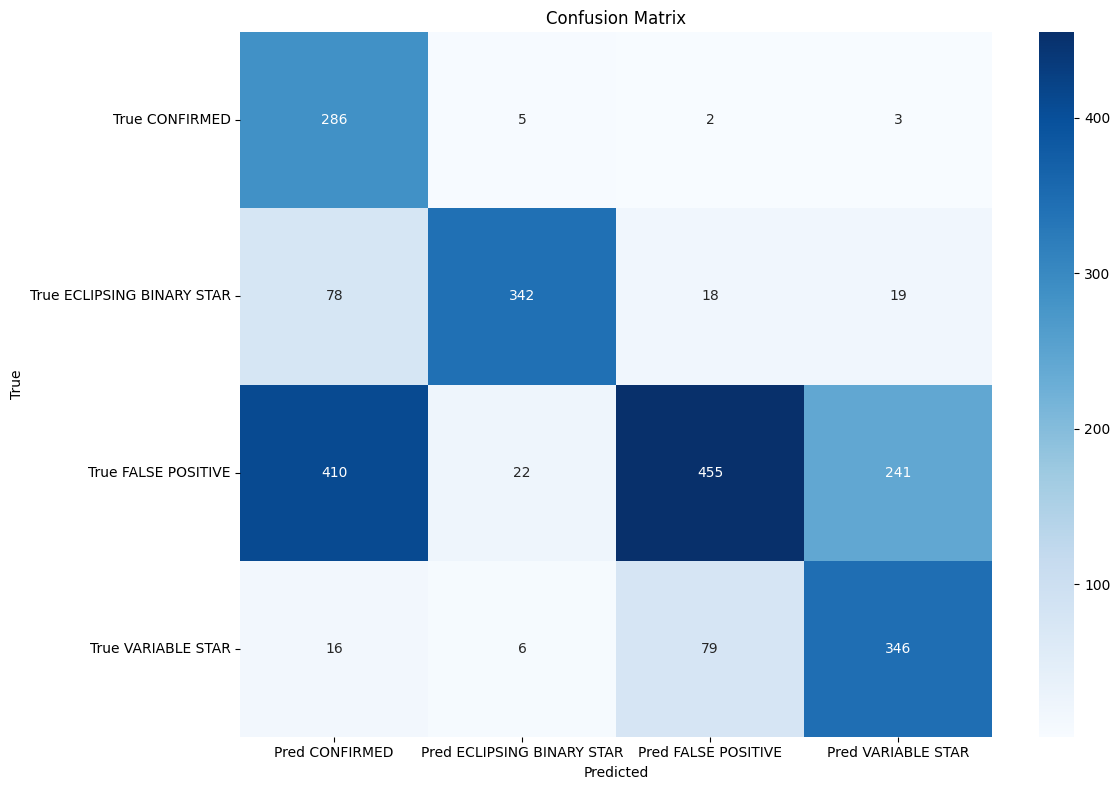

In [35]:
cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(cm, index=[f"True {c}" for c in class_names], columns=[f"Pred {c}" for c in class_names])
print("Confusion matrix:")
display(cm_df)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


#### 2.6.3 Misclassification Summary

In [36]:
# Misclassification summary
mis_mask = y_true != y_pred
mis_df = pd.DataFrame({
    "true": y_true[mis_mask],
    "pred": y_pred[mis_mask]
})

print("Misclassification summary:")
if len(mis_df) == 0:
    print("No misclassifications.")
else:
    mis_df["pair"] = list(zip(mis_df["true"], mis_df["pred"]))
    pair_counts = mis_df["pair"].value_counts()

    pretty_pairs = []
    for (t, p), n in pair_counts.items():
        pretty_pairs.append({
            "true": class_names[int(t)] if int(t) < len(class_names) else str(t),
            "pred": class_names[int(p)] if int(p) < len(class_names) else str(p),
            "count": int(n)
        })

    display(pd.DataFrame(pretty_pairs))


Misclassification summary:


,true,pred,count
0,FALSE POSITIVE,CONFIRMED,410
1,FALSE POSITIVE,VARIABLE STAR,241
2,VARIABLE STAR,FALSE POSITIVE,79
3,ECLIPSING BINARY STAR,CONFIRMED,78
4,FALSE POSITIVE,ECLIPSING BINARY STAR,22
5,ECLIPSING BINARY STAR,VARIABLE STAR,19
6,ECLIPSING BINARY STAR,FALSE POSITIVE,18
7,VARIABLE STAR,CONFIRMED,16
8,VARIABLE STAR,ECLIPSING BINARY STAR,6
9,CONFIRMED,ECLIPSING BINARY STAR,5
